In [1]:
from pathlib import Path

# 女生提供的 Stage 2 文件夹
stage2_dir = Path("new")

print("Stage 2 folder exists:", stage2_dir.exists())
print("\nFiles inside:")

for path in sorted(stage2_dir.rglob("*")):
    if path.is_file():
        print(path)

Stage 2 folder exists: True

Files inside:
new\new\build_report.json
new\new\purged\build_report.json
new\new\purged\stage2_test_2025.csv
new\new\purged\stage2_train_2025.csv
new\new\purged\stage2_validation_2025.csv
new\new\stage2_candidate_factor_table_2025.csv
new\new\stage2_test_2025.csv
new\new\stage2_train_2025.csv
new\new\stage2_validation_2025.csv
new\new\verification_report.json


In [3]:
from pathlib import Path
import json

# 找到原来的 Stage 1 HGBR notebook
matches = list(Path(".").glob("stage1_extra_hgbr_regression_taiyu*.ipynb"))

print("Found notebooks:")
for path in matches:
    print(path)

Found notebooks:
stage1_extra_hgbr_regression_taiyu.ipynb.ipynb


In [5]:

notebook_path = Path("stage1_extra_hgbr_regression_taiyu.ipynb.ipynb")

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

keywords = [
    "FEATURE",
    "feature",
    "AAPL",
    "Experiment A",
    "FEATURE_SETS"
]

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        source = "".join(cell["source"])

        if any(keyword in source for keyword in keywords):
            print(f"\n===== CODE CELL {i} =====")
            print(source[:2500])


===== CODE CELL 2 =====
import yfinance as yf
import pandas as pd
from pathlib import Path

aapl_5y = yf.download(
    "AAPL",
    start="2021-08-31",
    end="2026-09-01",
    interval="1d",
    auto_adjust=True,
    progress=False
)

print("Rows:", len(aapl_5y))
print("First date:", aapl_5y.index.min())
print("Last date:", aapl_5y.index.max())

display(aapl_5y.head())

===== CODE CELL 3 =====
import time

tickers = ["AAPL", "MSFT", "NVDA", "QQQ"]

raw_5y_dir =  Path("data/raw")
raw_5y_dir.mkdir(parents=True, exist_ok=True)

all_5y_data = []

for ticker in tickers:
    print(f"Downloading {ticker}...")

    df = yf.download(
        ticker,
        start="2021-08-31",
        end="2026-09-01",
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    # Flatten yfinance multi-level columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.reset_index()
    df.insert(0, "Ticker", ticker)

    # Keep a

In [7]:
# Phase 2 baseline: original 10 AAPL factors from Stage 1

BASE_FEATURES = [
    "log_return_1d",
    "log_return_5d",
    "log_return_20d",
    "close_to_ema_10",
    "close_to_ema_20",
    "rsi_14_scaled",
    "realized_vol_5",
    "realized_vol_20",
    "volume_change_1d",
    "volume_z_20"
]

print("Number of baseline factors:", len(BASE_FEATURES))

for i, feature in enumerate(BASE_FEATURES, start=1):
    print(f"{i:02d}. {feature}")

Number of baseline factors: 10
01. log_return_1d
02. log_return_5d
03. log_return_20d
04. close_to_ema_10
05. close_to_ema_20
06. rsi_14_scaled
07. realized_vol_5
08. realized_vol_20
09. volume_change_1d
10. volume_z_20


In [9]:
# ==========================================
# Phase 2 - Module 2
# Define LLM factor sets for A/B/C experiments
# ==========================================

# Experiment B:
# 4 LLM factors mainly using AAPL + QQQ information
LLM_B_FEATURES = [
    "aapl_to_qqq_relative_realized_risk",
    "relative_return_market_risk_interaction",
    "aapl_to_qqq_normalized_range_ratio",
    "lagged_qqq_relative_momentum"
]

# Experiment C:
# All 8 LLM-generated factors
LLM_C_FEATURES = [
    "peer_signed_return_confirmation",
    "peer_return_dispersion",
    "aapl_peer_consensus_relative_return",
    "aapl_to_qqq_relative_realized_risk",
    "peer_volume_confirmed_aapl_return",
    "relative_return_market_risk_interaction",
    "aapl_to_qqq_normalized_range_ratio",
    "lagged_qqq_relative_momentum"
]

# Final feature sets
FEATURES_A = BASE_FEATURES.copy()

FEATURES_B = (
    BASE_FEATURES
    + LLM_B_FEATURES
)

FEATURES_C = (
    BASE_FEATURES
    + LLM_C_FEATURES
)

print("Experiment A factors:", len(FEATURES_A))
print("Experiment B factors:", len(FEATURES_B))
print("Experiment C factors:", len(FEATURES_C))

Experiment A factors: 10
Experiment B factors: 14
Experiment C factors: 18


In [11]:
# ==========================================
# Phase 2 - Module 3
# Read and inspect Stage 2 purged datasets
# ==========================================

import pandas as pd
from pathlib import Path

# Stage 2 purged data folder
stage2_data_dir = Path("new") / "new" / "purged"

# Read train / validation / test
stage2_train = pd.read_csv(
    stage2_data_dir / "stage2_train_2025.csv",
    parse_dates=["Date"]
)

stage2_validation = pd.read_csv(
    stage2_data_dir / "stage2_validation_2025.csv",
    parse_dates=["Date"]
)

stage2_test = pd.read_csv(
    stage2_data_dir / "stage2_test_2025.csv",
    parse_dates=["Date"]
)

datasets = {
    "Train": stage2_train,
    "Validation": stage2_validation,
    "Test": stage2_test
}

for name, df in datasets.items():

    print(f"\n===== {name} =====")

    print("Shape:", df.shape)

    print(
        "Date range:",
        df["Date"].min().date(),
        "to",
        df["Date"].max().date()
    )

    # Check whether all 8 LLM factors exist
    missing_llm = [
        feature
        for feature in LLM_C_FEATURES
        if feature not in df.columns
    ]

    print("Missing LLM factors:", missing_llm)

    # Find target-related columns
    target_columns = [
        column
        for column in df.columns
        if "target" in column.lower()
    ]

    print("Target columns:", target_columns)


print("\n===== ALL COLUMNS =====")

for column in stage2_train.columns:
    print(column)


===== Train =====
Shape: (159, 33)
Date range: 2025-02-03 to 2025-09-19
Missing LLM factors: []
Target columns: ['target_return', 'target_date']

===== Validation =====
Shape: (33, 33)
Date range: 2025-09-23 to 2025-11-06
Missing LLM factors: []
Target columns: ['target_return', 'target_date']

===== Test =====
Shape: (35, 33)
Date range: 2025-11-10 to 2025-12-30
Missing LLM factors: []
Target columns: ['target_return', 'target_date']

===== ALL COLUMNS =====
Date
Quarter
Split
AAPL_Open
AAPL_High
AAPL_Low
AAPL_Close
AAPL_Volume
QQQ_Open
QQQ_High
QQQ_Low
QQQ_Close
QQQ_Volume
MSFT_Open
MSFT_High
MSFT_Low
MSFT_Close
MSFT_Volume
NVDA_Open
NVDA_High
NVDA_Low
NVDA_Close
NVDA_Volume
peer_signed_return_confirmation
peer_return_dispersion
aapl_peer_consensus_relative_return
aapl_to_qqq_relative_realized_risk
peer_volume_confirmed_aapl_return
relative_return_market_risk_interaction
aapl_to_qqq_normalized_range_ratio
lagged_qqq_relative_momentum
target_return
target_date


In [13]:
# ==========================================
# Phase 2 - Module 4.1
# Inspect the full Stage 2 factor table
# ==========================================

full_stage2_path = (
    Path("new")
    / "new"
    / "stage2_candidate_factor_table_2025.csv"
)

full_stage2 = pd.read_csv(
    full_stage2_path,
    parse_dates=["Date"]
)

print("Shape:", full_stage2.shape)

print(
    "Date range:",
    full_stage2["Date"].min().date(),
    "to",
    full_stage2["Date"].max().date()
)

print("Unique dates:", full_stage2["Date"].nunique())

print("\nAAPL raw columns:")

aapl_raw_columns = [
    "AAPL_Open",
    "AAPL_High",
    "AAPL_Low",
    "AAPL_Close",
    "AAPL_Volume"
]

for column in aapl_raw_columns:
    print(
        column,
        "->",
        column in full_stage2.columns
    )

print("\nTarget columns:")

for column in full_stage2.columns:
    if "target" in column.lower():
        print(column)

Shape: (229, 33)
Date range: 2025-02-03 to 2025-12-30
Unique dates: 229

AAPL raw columns:
AAPL_Open -> True
AAPL_High -> True
AAPL_Low -> True
AAPL_Close -> True
AAPL_Volume -> True

Target columns:
target_return
target_date


In [15]:
# ==========================================
# Phase 2 - Module 4.2
# Locate original full 2025 OHLCV dataset
# ==========================================

from pathlib import Path

possible_files = [
    Path("data/processed/aligned_daily_ohlcv_2025_split.csv"),
    Path("data/processed_1y_yahoo/aligned_daily_ohlcv_2025_split.csv"),
]

for path in possible_files:
    print(path, "->", path.exists())

data\processed\aligned_daily_ohlcv_2025_split.csv -> False
data\processed_1y_yahoo\aligned_daily_ohlcv_2025_split.csv -> True


In [17]:
# ==========================================
# Phase 2 - Module 4.3
# Load full 2025 OHLCV data
# ==========================================

full_2025_path = Path(
    "data/processed_1y_yahoo/aligned_daily_ohlcv_2025_split.csv"
)

full_2025 = pd.read_csv(
    full_2025_path,
    parse_dates=["Date"]
)

print("Shape:", full_2025.shape)

print(
    "Date range:",
    full_2025["Date"].min().date(),
    "to",
    full_2025["Date"].max().date()
)

print("Unique dates:", full_2025["Date"].nunique())

print("\nRows per ticker:")
print(full_2025["Ticker"].value_counts().sort_index())

Shape: (1000, 9)
Date range: 2025-01-02 to 2025-12-31
Unique dates: 250

Rows per ticker:
Ticker
AAPL    250
MSFT    250
NVDA    250
QQQ     250
Name: count, dtype: int64


In [19]:
# ==========================================
# Phase 2 - Module 4.4
# Inspect original Stage 1 factor formulas
# ==========================================

for i in range(22, 32):

    cell = nb["cells"][i]

    if cell["cell_type"] == "code":

        source = "".join(cell["source"])

        print(f"\n===== CODE CELL {i} =====")
        print(source)


===== CODE CELL 22 =====
import numpy as np

# Step 2: Calculate 1-day log return for AAPL

aapl["log_return_1d"] = np.log(aapl["Close"]).diff()

display(
    aapl[["Close", "log_return_1d"]].head(10)
)

===== CODE CELL 23 =====
# Step 3: Calculate 5-day log return (momentum)

aapl["log_return_5d"] = np.log(aapl["Close"]).diff(5)

display(
    aapl[["Close", "log_return_1d", "log_return_5d"]].head(10)
)

===== CODE CELL 24 =====
# Step 4: Calculate 20-day log return (momentum)

aapl["log_return_20d"] = np.log(aapl["Close"]).diff(20)

display(
    aapl[
        ["Close", "log_return_1d", "log_return_5d", "log_return_20d"]
    ].head(25)
)

===== CODE CELL 25 =====
# Step 5: Calculate 10-day EMA trend factor

ema_10 = aapl["Close"].ewm(span=10, adjust=False).mean()

aapl["close_to_ema_10"] = aapl["Close"] / ema_10 - 1

display(
    aapl[
        [
            "Close",
            "log_return_1d",
            "log_return_5d",
            "log_return_20d",
            "close_to_ema_10"
  

In [23]:
# ==========================================
# Phase 2 - Module 5
# Rebuild the original 10 Stage 1 factors
# ==========================================

import numpy as np
import pandas as pd


def rsi(series, window=14):
    change = series.diff()

    gain = change.clip(lower=0)
    loss = -change.clip(upper=0)

    avg_gain = gain.ewm(
        alpha=1 / window,
        adjust=False,
        min_periods=window
    ).mean()

    avg_loss = loss.ewm(
        alpha=1 / window,
        adjust=False,
        min_periods=window
    ).mean()

    relative_strength = avg_gain / avg_loss.replace(0, np.nan)

    return 100 - 100 / (1 + relative_strength)


def build_baseline_factors(aapl_df):
    df = aapl_df.copy()

    # 1. Log returns
    df["log_return_1d"] = np.log(df["Close"]).diff()
    df["log_return_5d"] = np.log(df["Close"]).diff(5)
    df["log_return_20d"] = np.log(df["Close"]).diff(20)

    # 2. EMA trend
    ema_10 = df["Close"].ewm(span=10, adjust=False).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()

    df["close_to_ema_10"] = df["Close"] / ema_10 - 1
    df["close_to_ema_20"] = df["Close"] / ema_20 - 1

    # 3. RSI
    df["rsi_14"] = rsi(df["Close"], 14)
    df["rsi_14_scaled"] = (df["rsi_14"] - 50) / 50

    # 4. Realized volatility
    df["realized_vol_5"] = (
        df["log_return_1d"]
        .rolling(5)
        .std()
        * np.sqrt(252)
    )

    df["realized_vol_20"] = (
        df["log_return_1d"]
        .rolling(20)
        .std()
        * np.sqrt(252)
    )

    # 5. Volume factors
    log_volume = np.log(df["Volume"].replace(0, np.nan))

    df["volume_change_1d"] = log_volume.diff()

    rolling_mean_20 = log_volume.rolling(20).mean()
    rolling_std_20 = log_volume.rolling(20).std()

    df["volume_z_20"] = (
        (log_volume - rolling_mean_20) / rolling_std_20
    )

    return df

In [25]:
# ==========================================
# Phase 2 - Module 5.1
# Build the 10 traditional factors for AAPL
# ==========================================

# Extract AAPL from the full 2025 dataset
aapl_full = (
    full_2025[full_2025["Ticker"] == "AAPL"]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

print("AAPL rows before factor calculation:", len(aapl_full))

# Build the original 10 Stage 1 factors
aapl_with_factors = build_baseline_factors(aapl_full)

print("AAPL rows after factor calculation:", len(aapl_with_factors))

print("\nBaseline factors:")
for feature in BASE_FEATURES:
    print(feature)

AAPL rows before factor calculation: 250
AAPL rows after factor calculation: 250

Baseline factors:
log_return_1d
log_return_5d
log_return_20d
close_to_ema_10
close_to_ema_20
rsi_14_scaled
realized_vol_5
realized_vol_20
volume_change_1d
volume_z_20


In [27]:
# ==========================================
# Phase 2 - Module 5.2
# Check baseline factor availability
# ==========================================

print("Missing values in baseline factors:\n")

print(
    aapl_with_factors[BASE_FEATURES]
    .isna()
    .sum()
)

# Keep only rows where all 10 baseline factors are available
baseline_usable = aapl_with_factors.dropna(
    subset=BASE_FEATURES
).copy()

print("\nUsable rows:", len(baseline_usable))

print(
    "Usable date range:",
    baseline_usable["Date"].min().date(),
    "to",
    baseline_usable["Date"].max().date()
)

Missing values in baseline factors:

log_return_1d        1
log_return_5d        5
log_return_20d      20
close_to_ema_10      0
close_to_ema_20      0
rsi_14_scaled       14
realized_vol_5       5
realized_vol_20     20
volume_change_1d     1
volume_z_20         19
dtype: int64

Usable rows: 230
Usable date range: 2025-02-03 to 2025-12-31


In [29]:
# ==========================================
# Phase 2 - Module 5.3
# Create next-day return target and verify date alignment
# ==========================================

# Same target definition as Stage 1
aapl_with_factors["target_return"] = np.log(
    aapl_with_factors["Close"].shift(-1)
    / aapl_with_factors["Close"]
)

# Keep rows with all 10 factors and a valid next-day target
baseline_ready = aapl_with_factors.dropna(
    subset=BASE_FEATURES + ["target_return"]
).copy()

print("Baseline ready rows:", len(baseline_ready))

print(
    "Date range:",
    baseline_ready["Date"].min().date(),
    "to",
    baseline_ready["Date"].max().date()
)

# Compare dates with the teammate's Stage 2 table
baseline_dates = baseline_ready["Date"].reset_index(drop=True)
stage2_dates = full_stage2["Date"].reset_index(drop=True)

print("\nSame number of dates:", len(baseline_dates) == len(stage2_dates))
print("Dates exactly identical:", baseline_dates.equals(stage2_dates))

Baseline ready rows: 229
Date range: 2025-02-03 to 2025-12-30

Same number of dates: True
Dates exactly identical: True


In [31]:
# ==========================================
# Phase 2 - Module 5.4
# Verify target_return consistency
# ==========================================

target_check = baseline_ready[
    ["Date", "target_return"]
].merge(
    full_stage2[
        ["Date", "target_return"]
    ],
    on="Date",
    how="inner",
    suffixes=("_stage1", "_stage2")
)

target_check["difference"] = (
    target_check["target_return_stage1"]
    - target_check["target_return_stage2"]
)

print("Rows compared:", len(target_check))

print(
    "Maximum absolute difference:",
    target_check["difference"].abs().max()
)

print(
    "Targets identical:",
    np.allclose(
        target_check["target_return_stage1"],
        target_check["target_return_stage2"]
    )
)

Rows compared: 229
Maximum absolute difference: 2.3454432175606943e-07
Targets identical: False


In [33]:
# ==========================================
# Phase 2 - Module 5.5
# Check AAPL Close consistency
# ==========================================

price_check = baseline_ready[
    ["Date", "Close"]
].merge(
    full_stage2[
        ["Date", "AAPL_Close"]
    ],
    on="Date",
    how="inner"
)

price_check["difference"] = (
    price_check["Close"]
    - price_check["AAPL_Close"]
)

print("Rows compared:", len(price_check))

print(
    "Maximum absolute Close difference:",
    price_check["difference"].abs().max()
)

print(
    "Mean absolute Close difference:",
    price_check["difference"].abs().mean()
)

print("\nLargest 5 differences:")

display(
    price_check
    .assign(abs_difference=price_check["difference"].abs())
    .sort_values("abs_difference", ascending=False)
    .head(5)
)

Rows compared: 229
Maximum absolute Close difference: 4.577636721592171e-05
Mean absolute Close difference: 1.0661162667354714e-05

Largest 5 differences:


,Date,Close,AAPL_Close,difference,abs_difference
9,2025-02-14,243.104706,243.104752,-0.000046,0.000046
1,2025-02-04,231.122772,231.122726,0.000046,0.000046
35,2025-03-25,222.382202,222.382172,0.000031,0.000031
12,2025-02-20,244.327209,244.327179,0.000031,0.000031
221,2025-12-18,271.451141,271.451111,0.000031,0.000031


In [35]:
# ==========================================
# Phase 2 - Module 6
# Build the master Phase 2 dataset
# ==========================================

# Keep only Date + the 10 traditional factors
traditional_table = baseline_ready[
    ["Date"] + BASE_FEATURES
].copy()

# Merge with teammate's Stage 2 table
phase2_master = full_stage2.merge(
    traditional_table,
    on="Date",
    how="inner"
)

print("Master dataset shape:", phase2_master.shape)

print(
    "Date range:",
    phase2_master["Date"].min().date(),
    "to",
    phase2_master["Date"].max().date()
)

print("Unique dates:", phase2_master["Date"].nunique())

print("\nMissing values in A/B/C features:")

print(
    "Experiment A:",
    phase2_master[FEATURES_A].isna().sum().sum()
)

print(
    "Experiment B:",
    phase2_master[FEATURES_B].isna().sum().sum()
)

print(
    "Experiment C:",
    phase2_master[FEATURES_C].isna().sum().sum()
)

print(
    "\nMissing target values:",
    phase2_master["target_return"].isna().sum()
)

Master dataset shape: (229, 43)
Date range: 2025-02-03 to 2025-12-30
Unique dates: 229

Missing values in A/B/C features:
Experiment A: 0
Experiment B: 0
Experiment C: 0

Missing target values: 0


In [37]:
# ==========================================
# Phase 2 - Module 7
# Apply the purged train / validation / test split
# ==========================================

# Use the exact dates from the teammate's purged datasets
train_dates = set(stage2_train["Date"])
validation_dates = set(stage2_validation["Date"])
test_dates = set(stage2_test["Date"])

# Split the master dataset by exact dates
phase2_train = phase2_master[
    phase2_master["Date"].isin(train_dates)
].copy()

phase2_validation = phase2_master[
    phase2_master["Date"].isin(validation_dates)
].copy()

phase2_test = phase2_master[
    phase2_master["Date"].isin(test_dates)
].copy()

# Sort chronologically
phase2_train = phase2_train.sort_values("Date").reset_index(drop=True)
phase2_validation = phase2_validation.sort_values("Date").reset_index(drop=True)
phase2_test = phase2_test.sort_values("Date").reset_index(drop=True)

print("Train rows     :", len(phase2_train))
print("Validation rows:", len(phase2_validation))
print("Test rows      :", len(phase2_test))

print("\nTrain range:")
print(
    phase2_train["Date"].min().date(),
    "to",
    phase2_train["Date"].max().date()
)

print("\nValidation range:")
print(
    phase2_validation["Date"].min().date(),
    "to",
    phase2_validation["Date"].max().date()
)

print("\nTest range:")
print(
    phase2_test["Date"].min().date(),
    "to",
    phase2_test["Date"].max().date()
)

# Check which 229 rows were excluded by purging
used_dates = train_dates | validation_dates | test_dates

excluded_rows = phase2_master[
    ~phase2_master["Date"].isin(used_dates)
][["Date", "target_date"]]

print("\nExcluded boundary rows:")
display(excluded_rows)

Train rows     : 159
Validation rows: 33
Test rows      : 35

Train range:
2025-02-03 to 2025-09-19

Validation range:
2025-09-23 to 2025-11-06

Test range:
2025-11-10 to 2025-12-30

Excluded boundary rows:


,Date,target_date
159,2025-09-22,2025-09-23
193,2025-11-07,2025-11-10


In [39]:
# ==========================================
# Phase 2 - Module 8
# Prepare X and y for Experiments A, B and C
# ==========================================

def prepare_xy(df, features):
    data = df.set_index("Date")

    X = data[features].copy()
    y = data["target_return"].copy()

    return X, y


# Experiment A
X_train_A, y_train_A = prepare_xy(
    phase2_train,
    FEATURES_A
)

X_validation_A, y_validation_A = prepare_xy(
    phase2_validation,
    FEATURES_A
)

X_test_A, y_test_A = prepare_xy(
    phase2_test,
    FEATURES_A
)


# Experiment B
X_train_B, y_train_B = prepare_xy(
    phase2_train,
    FEATURES_B
)

X_validation_B, y_validation_B = prepare_xy(
    phase2_validation,
    FEATURES_B
)

X_test_B, y_test_B = prepare_xy(
    phase2_test,
    FEATURES_B
)


# Experiment C
X_train_C, y_train_C = prepare_xy(
    phase2_train,
    FEATURES_C
)

X_validation_C, y_validation_C = prepare_xy(
    phase2_validation,
    FEATURES_C
)

X_test_C, y_test_C = prepare_xy(
    phase2_test,
    FEATURES_C
)


print("===== Experiment A =====")
print("Train     :", X_train_A.shape)
print("Validation:", X_validation_A.shape)
print("Test      :", X_test_A.shape)

print("\n===== Experiment B =====")
print("Train     :", X_train_B.shape)
print("Validation:", X_validation_B.shape)
print("Test      :", X_test_B.shape)

print("\n===== Experiment C =====")
print("Train     :", X_train_C.shape)
print("Validation:", X_validation_C.shape)
print("Test      :", X_test_C.shape)

print("\nTargets identical across A/B/C:")
print(
    y_train_A.equals(y_train_B)
    and y_train_A.equals(y_train_C)
    and y_validation_A.equals(y_validation_B)
    and y_validation_A.equals(y_validation_C)
    and y_test_A.equals(y_test_B)
    and y_test_A.equals(y_test_C)
)

===== Experiment A =====
Train     : (159, 10)
Validation: (33, 10)
Test      : (35, 10)

===== Experiment B =====
Train     : (159, 14)
Validation: (33, 14)
Test      : (35, 14)

===== Experiment C =====
Train     : (159, 18)
Validation: (33, 18)
Test      : (35, 18)

Targets identical across A/B/C:
True


In [41]:
# ==========================================
# Phase 2 - Module 9.1
# Inspect original HGBR model settings
# ==========================================

for i in range(38, 41):

    cell = nb["cells"][i]

    if cell["cell_type"] == "code":

        source = "".join(cell["source"])

        print(f"\n===== CODE CELL {i} =====")
        print(source)


===== CODE CELL 38 =====
# Step 18: Create the HGBR model

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

model_a = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "regressor",
            HistGradientBoostingRegressor(
                learning_rate=0.04,
                max_iter=300,
                max_leaf_nodes=15,
                min_samples_leaf=15,
                l2_regularization=2.0,
                early_stopping=False,
                random_state=42
            )
        ),
    ]
)

print(model_a)

===== CODE CELL 39 =====
# Step 19: Train HGBR for Experiment A

model_a.fit(X_train, y_train)

print("Experiment A training completed.")

===== CODE CELL 40 =====
# Step 20: Predict on the validation set

validation_pred_return = model_a.predict(X_validation)

print("Number of validation predictions:", 

In [43]:
# ==========================================
# Phase 2 - Module 9.2
# Create identical HGBR models for A/B/C
# ==========================================

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


def create_hgbr_model():
    model = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "regressor",
                HistGradientBoostingRegressor(
                    learning_rate=0.04,
                    max_iter=300,
                    max_leaf_nodes=15,
                    min_samples_leaf=15,
                    l2_regularization=2.0,
                    early_stopping=False,
                    random_state=42
                )
            ),
        ]
    )

    return model


# Create three independent models
model_A = create_hgbr_model()
model_B = create_hgbr_model()
model_C = create_hgbr_model()

print("Experiment A model:")
print(model_A)

print("\nExperiment B model:")
print(model_B)

print("\nExperiment C model:")
print(model_C)

Experiment A model:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('regressor',
                 HistGradientBoostingRegressor(early_stopping=False,
                                               l2_regularization=2.0,
                                               learning_rate=0.04, max_iter=300,
                                               max_leaf_nodes=15,
                                               min_samples_leaf=15,
                                               random_state=42))])

Experiment B model:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('regressor',
                 HistGradientBoostingRegressor(early_stopping=False,
                                               l2_regularization=2.0,
                                               learning_rate=0.04, max_iter=300,
                                               max_leaf_nodes=15,
                                               min_samples_leaf=15

In [45]:
# ==========================================
# Phase 2 - Module 9.3
# Train Experiment A baseline
# ==========================================

# Train the baseline model
model_A.fit(
    X_train_A,
    y_train_A
)

print("Experiment A training completed.")

# Predict on validation set
validation_pred_A = model_A.predict(
    X_validation_A
)

print(
    "Number of validation predictions:",
    len(validation_pred_A)
)

# Show first 10 actual vs predicted values
comparison_A = pd.DataFrame(
    {
        "Actual_Return": y_validation_A,
        "Predicted_Return": validation_pred_A
    }
)

display(comparison_A.head(10))

Experiment A training completed.
Number of validation predictions: 33


E:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "E:\anaconda\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "E:\anaconda\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "E:\anaconda\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "E:\anaconda\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


,Actual_Return,Predicted_Return
Date,,
2025-09-23,-0.008367,0.006383
2025-09-24,0.017912,0.000979
2025-09-25,-0.005504,0.006672
2025-09-26,-0.004040,-0.004422
2025-09-29,0.000786,-0.011198
2025-09-30,0.003215,-0.015050
2025-10-01,0.006555,-0.010794
2025-10-02,0.003455,-0.008700
2025-10-03,-0.005168,-0.008727


In [47]:
# ==========================================
# Phase 2 - Module 9.4
# Evaluate Experiment A on validation set
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
mae_A = mean_absolute_error(
    y_validation_A,
    validation_pred_A
)

# RMSE
rmse_A = np.sqrt(
    mean_squared_error(
        y_validation_A,
        validation_pred_A
    )
)

# R-squared
r2_A = r2_score(
    y_validation_A,
    validation_pred_A
)

# Directional Accuracy
direction_A = np.mean(
    np.sign(y_validation_A.values)
    ==
    np.sign(validation_pred_A)
)

# Spearman Information Coefficient
spearman_A = pd.Series(
    validation_pred_A,
    index=y_validation_A.index
).corr(
    y_validation_A,
    method="spearman"
)

print("=== Experiment A: Validation Results ===")
print(f"MAE                 : {mae_A:.6f}")
print(f"RMSE                : {rmse_A:.6f}")
print(f"R²                  : {r2_A:.4f}")
print(f"Directional Accuracy: {direction_A:.2%}")
print(f"Spearman IC         : {spearman_A:.4f}")

=== Experiment A: Validation Results ===
MAE                 : 0.011720
RMSE                : 0.013409
R²                  : -0.1614
Directional Accuracy: 54.55%
Spearman IC         : 0.1695


In [49]:
# ==========================================
# Phase 2 - Module 9.5
# Train Experiment B
# 10 traditional + 4 LLM factors
# ==========================================

model_B.fit(
    X_train_B,
    y_train_B
)

print("Experiment B training completed.")

# Predict on validation set
validation_pred_B = model_B.predict(
    X_validation_B
)

print(
    "Number of validation predictions:",
    len(validation_pred_B)
)

comparison_B = pd.DataFrame(
    {
        "Actual_Return": y_validation_B,
        "Predicted_Return": validation_pred_B
    }
)

display(comparison_B.head(10))

Experiment B training completed.
Number of validation predictions: 33


,Actual_Return,Predicted_Return
Date,,
2025-09-23,-0.008367,0.004910
2025-09-24,0.017912,0.005094
2025-09-25,-0.005504,0.007957
2025-09-26,-0.004040,-0.003636
2025-09-29,0.000786,-0.008181
2025-09-30,0.003215,-0.012458
2025-10-01,0.006555,-0.006754
2025-10-02,0.003455,-0.003024
2025-10-03,-0.005168,-0.001152


In [51]:
# ==========================================
# Phase 2 - Module 9.6
# Evaluate Experiment B on validation set
# ==========================================

# MAE
mae_B = mean_absolute_error(
    y_validation_B,
    validation_pred_B
)

# RMSE
rmse_B = np.sqrt(
    mean_squared_error(
        y_validation_B,
        validation_pred_B
    )
)

# R-squared
r2_B = r2_score(
    y_validation_B,
    validation_pred_B
)

# Directional Accuracy
direction_B = np.mean(
    np.sign(y_validation_B.values)
    ==
    np.sign(validation_pred_B)
)

# Spearman IC
spearman_B = pd.Series(
    validation_pred_B,
    index=y_validation_B.index
).corr(
    y_validation_B,
    method="spearman"
)

print("=== Experiment B: Validation Results ===")
print(f"MAE                 : {mae_B:.6f}")
print(f"RMSE                : {rmse_B:.6f}")
print(f"R²                  : {r2_B:.4f}")
print(f"Directional Accuracy: {direction_B:.2%}")
print(f"Spearman IC         : {spearman_B:.4f}")

print("\n=== A vs B ===")

comparison_AB = pd.DataFrame({
    "Experiment": ["A", "B"],
    "Factors": [10, 14],
    "MAE": [mae_A, mae_B],
    "RMSE": [rmse_A, rmse_B],
    "R2": [r2_A, r2_B],
    "Directional_Accuracy": [direction_A, direction_B],
    "Spearman_IC": [spearman_A, spearman_B]
})

display(comparison_AB.round(4))

=== Experiment B: Validation Results ===
MAE                 : 0.011237
RMSE                : 0.015275
R²                  : -0.5072
Directional Accuracy: 45.45%
Spearman IC         : -0.0361

=== A vs B ===


,Experiment,Factors,MAE,RMSE,R2,Directional_Accuracy,Spearman_IC
0,A,10,0.0117,0.0134,-0.1614,0.5455,0.1695
1,B,14,0.0112,0.0153,-0.5072,0.4545,-0.0361


In [53]:
# ==========================================
# Phase 2 - Module 9.7
# Train Experiment C
# 10 traditional + 8 LLM factors
# ==========================================

model_C.fit(
    X_train_C,
    y_train_C
)

print("Experiment C training completed.")

# Predict on validation set
validation_pred_C = model_C.predict(
    X_validation_C
)

print(
    "Number of validation predictions:",
    len(validation_pred_C)
)

comparison_C = pd.DataFrame(
    {
        "Actual_Return": y_validation_C,
        "Predicted_Return": validation_pred_C
    }
)

display(comparison_C.head(10))

Experiment C training completed.
Number of validation predictions: 33


,Actual_Return,Predicted_Return
Date,,
2025-09-23,-0.008367,0.007578
2025-09-24,0.017912,0.001104
2025-09-25,-0.005504,0.014204
2025-09-26,-0.004040,0.001514
2025-09-29,0.000786,-0.003959
2025-09-30,0.003215,-0.007180
2025-10-01,0.006555,-0.002007
2025-10-02,0.003455,-0.004041
2025-10-03,-0.005168,-0.003121


In [55]:
# ==========================================
# Phase 2 - Module 9.8
# Evaluate Experiment C and compare A/B/C
# ==========================================

# MAE
mae_C = mean_absolute_error(
    y_validation_C,
    validation_pred_C
)

# RMSE
rmse_C = np.sqrt(
    mean_squared_error(
        y_validation_C,
        validation_pred_C
    )
)

# R-squared
r2_C = r2_score(
    y_validation_C,
    validation_pred_C
)

# Directional Accuracy
direction_C = np.mean(
    np.sign(y_validation_C.values)
    ==
    np.sign(validation_pred_C)
)

# Spearman IC
spearman_C = pd.Series(
    validation_pred_C,
    index=y_validation_C.index
).corr(
    y_validation_C,
    method="spearman"
)

print("=== Experiment C: Validation Results ===")
print(f"MAE                 : {mae_C:.6f}")
print(f"RMSE                : {rmse_C:.6f}")
print(f"R²                  : {r2_C:.4f}")
print(f"Directional Accuracy: {direction_C:.2%}")
print(f"Spearman IC         : {spearman_C:.4f}")


# Full A/B/C comparison
validation_results = pd.DataFrame({
    "Experiment": [
        "A: Traditional",
        "B: Traditional + 4 LLM",
        "C: Traditional + 8 LLM"
    ],
    "Factors": [10, 14, 18],
    "MAE": [mae_A, mae_B, mae_C],
    "RMSE": [rmse_A, rmse_B, rmse_C],
    "R2": [r2_A, r2_B, r2_C],
    "Directional_Accuracy": [
        direction_A,
        direction_B,
        direction_C
    ],
    "Spearman_IC": [
        spearman_A,
        spearman_B,
        spearman_C
    ]
})

print("\n=== A/B/C Validation Comparison ===")

display(
    validation_results.round(4)
)

=== Experiment C: Validation Results ===
MAE                 : 0.011929
RMSE                : 0.015996
R²                  : -0.6529
Directional Accuracy: 51.52%
Spearman IC         : -0.2276

=== A/B/C Validation Comparison ===


,Experiment,Factors,MAE,RMSE,R2,Directional_Accuracy,Spearman_IC
0,A: Traditional,10,0.0117,0.0134,-0.1614,0.5455,0.1695
1,B: Traditional + 4 LLM,14,0.0112,0.0153,-0.5072,0.4545,-0.0361
2,C: Traditional + 8 LLM,18,0.0119,0.0160,-0.6529,0.5152,-0.2276


In [57]:
# ==========================================
# Phase 2 - Module 10.1
# Predict on the untouched test set
# ==========================================

test_pred_A = model_A.predict(
    X_test_A
)

test_pred_B = model_B.predict(
    X_test_B
)

test_pred_C = model_C.predict(
    X_test_C
)

print("Experiment A test predictions:", len(test_pred_A))
print("Experiment B test predictions:", len(test_pred_B))
print("Experiment C test predictions:", len(test_pred_C))

print("\nFirst 5 Experiment A predictions:")

test_preview_A = pd.DataFrame(
    {
        "Actual_Return": y_test_A,
        "Predicted_Return": test_pred_A
    }
)

display(test_preview_A.head())

Experiment A test predictions: 35
Experiment B test predictions: 35
Experiment C test predictions: 35

First 5 Experiment A predictions:


,Actual_Return,Predicted_Return
Date,,
2025-11-10,0.021371,-0.005255
2025-11-11,-0.006488,0.012157
2025-11-12,-0.001903,0.001512
2025-11-13,-0.001980,0.004982
2025-11-14,-0.018338,0.004352


In [59]:
# ==========================================
# Phase 2 - Module 10.2
# Evaluate A/B/C on the test set
# ==========================================

def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        ),

        "R2": r2_score(
            y_true,
            y_pred
        ),

        "Directional_Accuracy": np.mean(
            np.sign(y_true.values)
            ==
            np.sign(y_pred)
        ),

        "Spearman_IC": pd.Series(
            y_pred,
            index=y_true.index
        ).corr(
            y_true,
            method="spearman"
        )
    }


# Evaluate the three experiments
test_A_results = evaluate_regression(
    y_test_A,
    test_pred_A
)

test_B_results = evaluate_regression(
    y_test_B,
    test_pred_B
)

test_C_results = evaluate_regression(
    y_test_C,
    test_pred_C
)


# Put all results into one table
test_results = pd.DataFrame([
    {
        "Experiment": "A: Traditional",
        "Factors": 10,
        **test_A_results
    },
    {
        "Experiment": "B: Traditional + 4 LLM",
        "Factors": 14,
        **test_B_results
    },
    {
        "Experiment": "C: Traditional + 8 LLM",
        "Factors": 18,
        **test_C_results
    }
])

print("=== A/B/C Test Comparison ===")

display(
    test_results.round(4)
)

=== A/B/C Test Comparison ===


,Experiment,Factors,MAE,RMSE,R2,Directional_Accuracy,Spearman_IC
0,A: Traditional,10,0.0103,0.0126,-0.9584,0.4571,0.0196
1,B: Traditional + 4 LLM,14,0.0121,0.0147,-1.6848,0.4286,-0.1807
2,C: Traditional + 8 LLM,18,0.0130,0.0170,-2.5817,0.3714,-0.3933


In [61]:
# ==========================================
# Phase 2 - Module 10.3
# Combine Validation and Test results
# ==========================================

final_comparison = pd.DataFrame({
    "Experiment": [
        "A: Traditional",
        "B: Traditional + 4 LLM",
        "C: Traditional + 8 LLM"
    ],

    "Factors": [10, 14, 18],

    "Val_MAE": [
        mae_A,
        mae_B,
        mae_C
    ],

    "Test_MAE": [
        test_A_results["MAE"],
        test_B_results["MAE"],
        test_C_results["MAE"]
    ],

    "Val_RMSE": [
        rmse_A,
        rmse_B,
        rmse_C
    ],

    "Test_RMSE": [
        test_A_results["RMSE"],
        test_B_results["RMSE"],
        test_C_results["RMSE"]
    ],

    "Val_R2": [
        r2_A,
        r2_B,
        r2_C
    ],

    "Test_R2": [
        test_A_results["R2"],
        test_B_results["R2"],
        test_C_results["R2"]
    ],

    "Val_Direction": [
        direction_A,
        direction_B,
        direction_C
    ],

    "Test_Direction": [
        test_A_results["Directional_Accuracy"],
        test_B_results["Directional_Accuracy"],
        test_C_results["Directional_Accuracy"]
    ],

    "Val_Spearman": [
        spearman_A,
        spearman_B,
        spearman_C
    ],

    "Test_Spearman": [
        test_A_results["Spearman_IC"],
        test_B_results["Spearman_IC"],
        test_C_results["Spearman_IC"]
    ]
})

display(final_comparison.round(4))

,Experiment,Factors,Val_MAE,Test_MAE,Val_RMSE,Test_RMSE,Val_R2,Test_R2,Val_Direction,Test_Direction,Val_Spearman,Test_Spearman
0,A: Traditional,10,0.0117,0.0103,0.0134,0.0126,-0.1614,-0.9584,0.5455,0.4571,0.1695,0.0196
1,B: Traditional + 4 LLM,14,0.0112,0.0121,0.0153,0.0147,-0.5072,-1.6848,0.4545,0.4286,-0.0361,-0.1807
2,C: Traditional + 8 LLM,18,0.0119,0.0130,0.0160,0.0170,-0.6529,-2.5817,0.5152,0.3714,-0.2276,-0.3933


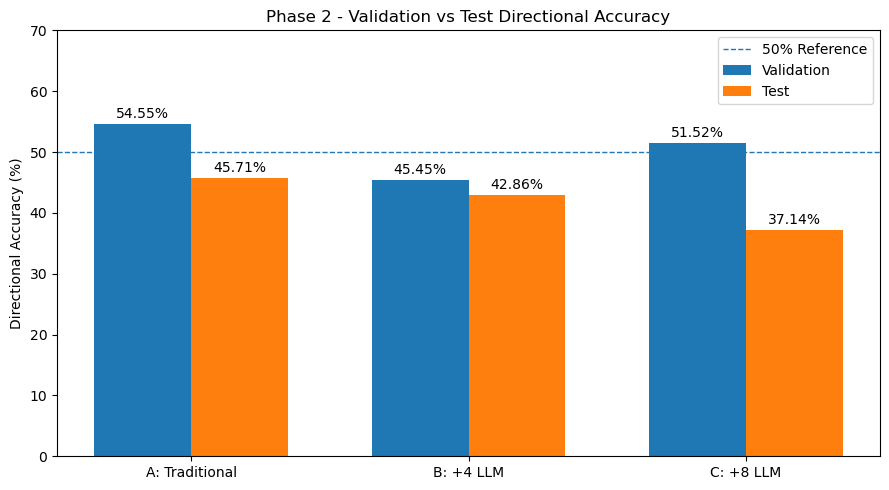

In [63]:
# ==========================================
# Phase 2 - Module 10.4
# Validation vs Test Directional Accuracy
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

labels = [
    "A: Traditional",
    "B: +4 LLM",
    "C: +8 LLM"
]

validation_accuracy = [
    direction_A * 100,
    direction_B * 100,
    direction_C * 100
]

test_accuracy = [
    test_A_results["Directional_Accuracy"] * 100,
    test_B_results["Directional_Accuracy"] * 100,
    test_C_results["Directional_Accuracy"] * 100
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))

bars1 = plt.bar(
    x - width / 2,
    validation_accuracy,
    width,
    label="Validation"
)

bars2 = plt.bar(
    x + width / 2,
    test_accuracy,
    width,
    label="Test"
)

plt.ylabel("Directional Accuracy (%)")
plt.title("Phase 2 - Validation vs Test Directional Accuracy")

plt.xticks(x, labels)

plt.ylim(0, 70)

plt.axhline(
    y=50,
    linestyle="--",
    linewidth=1,
    label="50% Reference"
)

plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.2f}%",
            ha="center"
        )

plt.tight_layout()
plt.show()

In [65]:
# ==========================================
# Phase 2 - Module 11.1
# Permutation importance for Experiment C
# ==========================================

from sklearn.inspection import permutation_importance

importance_C = permutation_importance(
    model_C,
    X_validation_C,
    y_validation_C,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42
)

importance_frame_C = pd.DataFrame({
    "Factor": FEATURES_C,
    "Importance": importance_C.importances_mean
})

importance_frame_C = importance_frame_C.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_frame_C)

,Factor,Importance
0,aapl_to_qqq_relative_realized_risk,0.000491
1,log_return_1d,0.000389
2,lagged_qqq_relative_momentum,0.000331
3,log_return_5d,0.000213
4,close_to_ema_20,0.000169
5,realized_vol_20,0.000135
6,rsi_14_scaled,0.000032
7,realized_vol_5,0.000026
8,relative_return_market_risk_interaction,0.000013
9,aapl_peer_consensus_relative_return,0.000011


,Factor,Type,Importance
0,aapl_to_qqq_relative_realized_risk,LLM,0.000491
1,log_return_1d,Traditional,0.000389
2,lagged_qqq_relative_momentum,LLM,0.000331
3,log_return_5d,Traditional,0.000213
4,close_to_ema_20,Traditional,0.000169
5,realized_vol_20,Traditional,0.000135
6,rsi_14_scaled,Traditional,0.000032
7,realized_vol_5,Traditional,0.000026
8,relative_return_market_risk_interaction,LLM,0.000013
9,aapl_peer_consensus_relative_return,LLM,0.000011


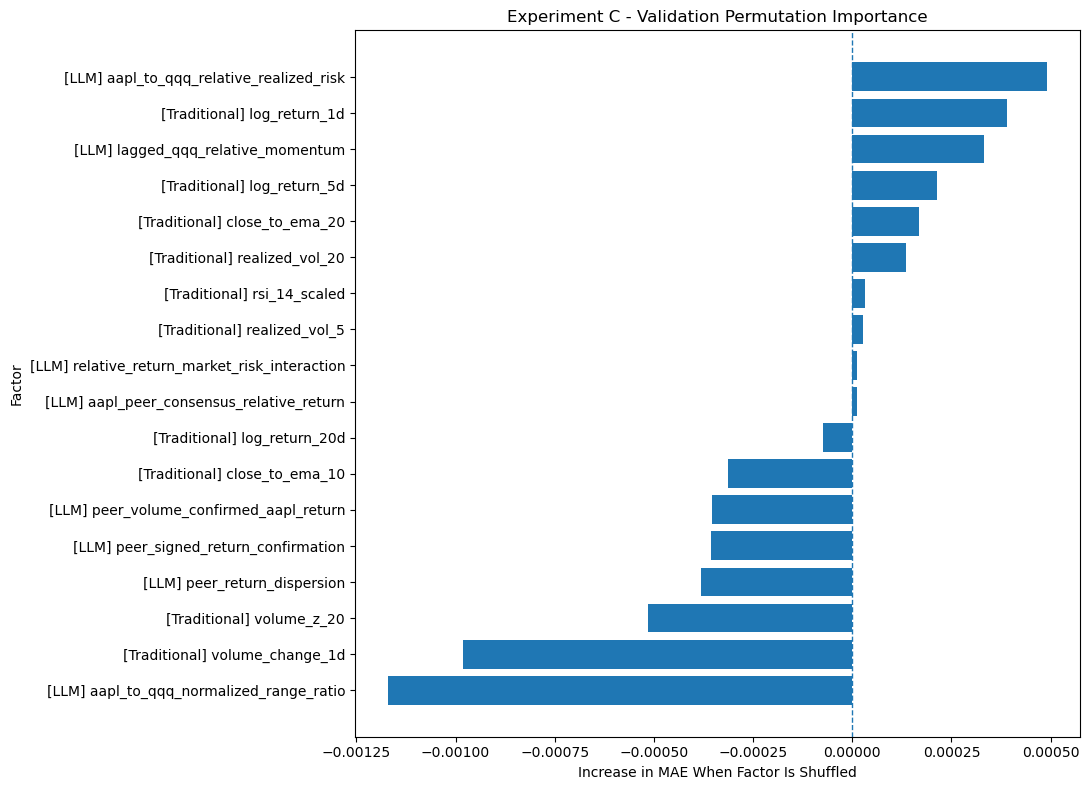

In [67]:
# ==========================================
# Phase 2 - Module 11.2
# Label and plot Experiment C factor importance
# ==========================================

# Label each factor as Traditional or LLM
importance_frame_C["Type"] = importance_frame_C["Factor"].apply(
    lambda x: "LLM" if x in LLM_C_FEATURES else "Traditional"
)

# Create readable labels for the plot
importance_frame_C["Plot_Label"] = (
    "[" + importance_frame_C["Type"] + "] "
    + importance_frame_C["Factor"]
)

display(
    importance_frame_C[
        ["Factor", "Type", "Importance"]
    ]
)


# Plot
plot_data = importance_frame_C.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(11, 8))

plt.barh(
    plot_data["Plot_Label"],
    plot_data["Importance"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Increase in MAE When Factor Is Shuffled")
plt.ylabel("Factor")

plt.title(
    "Experiment C - Validation Permutation Importance"
)

plt.tight_layout()
plt.show()

In [69]:
# ==========================================
# Phase 2 - Module 12.1
# Save final result tables
# ==========================================

from pathlib import Path

output_dir = Path("phase2_results")
output_dir.mkdir(exist_ok=True)

# Save Validation + Test comparison
final_comparison.to_csv(
    output_dir / "phase2_abc_validation_test_results.csv",
    index=False
)

# Save Experiment C permutation importance
importance_frame_C[
    ["Factor", "Type", "Importance"]
].to_csv(
    output_dir / "phase2_experiment_c_factor_importance.csv",
    index=False
)

print("Saved:")
print(output_dir / "phase2_abc_validation_test_results.csv")
print(output_dir / "phase2_experiment_c_factor_importance.csv")

Saved:
phase2_results\phase2_abc_validation_test_results.csv
phase2_results\phase2_experiment_c_factor_importance.csv
